In [89]:
import geopandas as gpd
from shapely import make_valid

In [90]:
# Set path only

gpkg_path = "../1_dataset/raw/processed/lagos_data.gpkg"

In [91]:
# List Layers (with Try-Except)

try:
    layers_df = gpd.io.file._list_layers(gpkg_path)
except FileNotFoundError:
    print (f"Error: Geopackage not found at {gpkg_path}")
    layers_df = None
except Exception as e:
    print (f"Error listing layers: {e}")
    layers_df = None

In [92]:
# Print Full Layer Details Only

if layers_df is not None:
    print ("Full layer details:")
    print (layers_df)
else:
    print ("No layer details available (load failed).")

Full layer details:
                                                name    geometry_type
0  lagos_boundaryshp__nga_admbnda_adm2_osgof_2017...     MultiPolygon
1                                        roads_lagos  MultiLineString
2                                    buildings_lagos     MultiPolygon
3                                         pois_lagos     MultiPolygon
4                                    buildings_clean     MultiPolygon
5                                        roads_clean  MultiLineString
6                                         pois_clean     MultiPolygon


In [93]:
# Extract Layer Names Only

if layers_df is not None:
    layer_names = layers_df['name'].tolist()
else:
    layer_names = []

In [94]:
print ("\nLayer names:", layer_names)



Layer names: ['lagos_boundaryshp__nga_admbnda_adm2_osgof_20170222', 'roads_lagos', 'buildings_lagos', 'pois_lagos', 'buildings_clean', 'roads_clean', 'pois_clean']


In [95]:
# Load Boundary (with Try-Except)

try:
    boundary = gpd.read_file(gpkg_path, layer = layer_names[0])
except FileNotFoundError:
    print (f"Error: GeoPackage not found at {gpkg_path}")
    boundary = None
except Exception as e:
    print (f"Error loading boundary: {e}")
    boundary = None
    

In [96]:
# Print Boundary Shape/CRS only

if boundary is not None:
    print (f"Boundary: {boundary.shape}, CRS:{boundary.crs}")
else:
    print ("Boundary not loaded")

Boundary: (2, 15), CRS:EPSG:4326


In [97]:
# Load Roads (with Try-Except)

try:
    roads = gpd.read_file(gpkg_path, layer = layer_names[1])
except FileNotFoundError:
    print (f"Error: Geopackage not found at {gpkg_path}")
    roads = None
except Exception as e:
    print (f"Error loading roads: {e}")
    roads = None

In [98]:
# Print Roads Shape/CRS only

if roads is not None:
    print (f"Roads: {roads.shape}, CRS: {roads.crs}")
else:
    print("Roads not loaded.")

Roads: (2568, 11), CRS: EPSG:4326


In [99]:
# Loads Buildings (with Try-Except)

try:
    buildings = gpd.read_file (gpkg_path, layer = layer_names[2])
except FileNotFoundError:
    print (f"Error: Geopackage not found at {gpkg_path}")
    buildings = None
except Exception as e:
    print (f"Error laoding buildings: {e}")
    buildings = None

In [100]:
# Print Buildings Shape/CRS only
if buildings is not None:
    print (f"Buildings: {buildings.shape}, CRS: {buildings.crs}")
else:
    print ("Buildings not loaded")

Buildings: (12212, 6), CRS: EPSG:4326


In [101]:
#Loads POIs (with Try-Except)

try:
    pois = gpd.read_file(gpkg_path, layer = layer_names[3])
except FileNotFoundError:
    print (f"Error: Geopackage not Found at {gpkg_path}")
    pois = None
except Exception as e:
    print (f"Error loading POIs: {e}")
    pois = None

In [102]:
if pois is not None:
    print (f"POIs: {pois.shape}, CRS: {pois.crs}")
else:
    print ("POIs not loaded")

POIs: (143, 5), CRS: EPSG:4326


In [103]:
# Check/Repair Boundary Geometries Only

if boundary is not None:
    invalid_count = (~boundary.geometry.is_valid).sum()
    if invalid_count > 0:
        print(f"Repairing {invalid_count} invalid in boundary...")
        boundary.geometry = boundary.geometry.apply (make_valid)
        print ("Repaired boundary")        

In [104]:
if roads is not None:
    invalid_count = (~roads.geometry.is_valid).sum()
    if invalid_count > 0:
        print (f"Repairing {invalid_count} invalid in buidlings...")
        roads.geometry = roads.geometry.apply(make_valid)
        print ("Repaired roads.") 

In [105]:
#Check/Repair Buildings Geometries Only

if buildings is not None:
    invalid_count = (~buildings.geometry.is_valid).sum()
    if invalid_count > 0:
        print ("Repairing {invalid_count} invalid in buildings....")
        buildings.geometry = buildings.geometry.apply(make_valid)
        print ("Repaired buildings")

In [106]:
# Check/Repair POIs Geometries Only

if pois is not None:
    invalid_count = (~pois.geometry.is_valid).sum()
    if invalid_count > 0:
        print (f"Repairing {invalid_count} invalid in pois...")
        pois.geometry = pois.geometry.apply (make_valid)
        print ("Repaired pois.")

In [107]:
#Set Target CRS Only

target_crs = "EPSG:4326"

In [108]:
# Reproject Boundary if Needed Only

if boundary is not None and boundary.crs != target_crs:
    print ("Reprojecting boundary...")
    boundary = boundary.to_crs(target_crs)

In [109]:
# Reproject Roads if Needed Only

if roads is not None and roads.crs != target_crs:
    print ("Reprojecting roads...")
    roads = roads.to_crs (target_crs)

In [110]:
# Reproject Buildings if Needed Only

if buildings is not None and buildings.crs != target_crs:
    print ("Reprojecting buildings...")
    buildings = buildings.to_crs (target_crs)

In [111]:
# Reproject POIs if Needed only

if pois is not None and pois.crs != target_crs:
    print ("Reprojecting pois...")
    pois = pois.to_crs(target_crs)

In [112]:
# Clean Roads Columns Only

if roads is not None:
    if 'highway' in roads.columns:
        roads_clean = roads [['highway', 'geometry']]
    else:
        roads_clean = roads[['geometry']]
else:
    roads_clean = None

In [113]:
# Print Roads Clean Shape Only

if roads_clean is not None:
    print (f"Roads_clean: {roads_clean.shape}")
else:
    print ("Roads not cleaned (not loaded).")

Roads_clean: (2568, 1)


In [114]:
#Clean Buildings Columns Only

if buildings is not None:
    buildings_clean = buildings [["geometry"]]
else:
    buildings_clean = None

In [115]:
#Print Buildings Clean Shape Only

if buildings_clean is not None:
    print (f"Buildings clean: {buildings_clean.shape}")
else:
    buildings_clean = None

Buildings clean: (12212, 1)


In [116]:
if pois is not None:
    if 'fclass' in pois.columns:
        pois_clean = pois[['fclass', 'geometry']]
    else:
        pois_clean = pois[['geometry']]
        
else:
    pois_clean = None

In [117]:
# Print POIs Clean Shape Only

if pois_clean is not None:
    print (f"POIs clean: {pois_clean.shape}")
else:
    print ("POIs not cleaned(not loaded).")

POIs clean: (143, 2)


In [118]:
buildings_clean.to_file ("../1_dataset/raw/processed/lagos_data.gpkg",
                         layer="buildings_clean", driver = "GPKG")

In [119]:
roads_clean.to_file ("../1_dataset/raw/processed/lagos_data.gpkg",
                     layer = "roads_clean", driver ="GPKG")

pois_clean.to_file ("../1_dataset/raw/processed/lagos_data.gpkg",
                    layer="pois_clean", driver = "GPKG")

In [120]:
import fiona
fiona.listlayers("../1_dataset/raw/processed/lagos_data.gpkg")

['lagos_boundaryshp__nga_admbnda_adm2_osgof_20170222',
 'roads_lagos',
 'buildings_lagos',
 'pois_lagos',
 'buildings_clean',
 'roads_clean',
 'pois_clean']

In [121]:
from typing import Dict, Optional, Tuple
import pandas as pd # For the summary table at the end

In [122]:
# Define the validate_and_fix function

def validate_and_fix (gdf: Optional [gpd.GeoDataFrame], name: str ='layer') \
    -> Tuple [Optional [gpd.GeoDataFrame], Dict]:
    """
    Validates and fixes GeoDataFrame: removes nulls, fixes invalids, checks CRS.
    
    Returns: (cleaned_gdf, stats_dict) where stats has 'before', 'after',
    'nulls_removed', etc.

    """
    
    stats = {'name': name, 'before': 0, 'after':0, 'nulls_removed':0, 'invalid_found':0,
           'invalids_fixed':0, 'remaining_invalids':0, 'crs_set': False }
    
    if gdf is None or gdf.empty:
        print (f"{name}: No data found or empty.")
        return None, stats
    
    print (f"\n Validating {name}.({len(gdf)} features)...")
    stats['before'] = len (gdf)

    # Remove null geometries

    null_mask = gdf.geometry.notnull()
    stats['nulls_removed'] = (~null_mask).sum()
    gdf = gdf[null_mask].copy() # .copy() to avoid SettingWithCopyWarning
    stats['after'] = len(gdf)
    print (f" - Removed {stats ['nulls_removed']} null geometries.")
    
    if stats ['after'] == 0:
        print (f"{name}: Empty after null removal")
        return None, stats
    
    # Fix invalid geometries
    
    invalid_mask = ~gdf.is_valid
    stats['invalids_found'] = invalid_mask.sum()
    print (f" - Found {stats ['invalids_found']} invalid geometries.")
    
    if stats ['invalids_found'] > 0:
        # Primary fix: buffer(0) for most cases
        gdf.loc[invalid_mask, 'geometry'] =  gdf.loc [invalid_mask, 'geometry'].buffer(0)
        still_invalid_after_buffer = (~gdf[invalid_mask].is_valid).sum()
        stats ['invalids_fixed'] += (stats['invalids_found'] -still_invalid_after_buffer)
        
    # Fallback: explosive union for stubborn cases (e.g., degenerate ponts/lines)
    
    still_invalid = ~gdf.is_valid
    if still_invalid.sum() > 0:
        fixed_geoms = gdf[still_invalid].unary_union.explode (index_parts= False)
        #Note: This assumes the exploded geoms align with indices; adjust if needed for large
        #datasets
        gdf.loc[still_invalid,'geometry'] = gpd.GeoSeries (fixed_geoms, crs = gdf.crs).iloc[:still_invalid.sum()]
        stats['invalids_fixed'] += still_invalid.sum()
        
    stats['remaining_invalids'] = (~gdf.is_valid).sum()
    print (f" - Fixed {stats['invalids_fixed']} invalid geometries.")
    if stats['remaining_invalids'] > 0:
        print (f" Warning: {stats[remaining_invalids]} still invalid-consider manual review.")
        
#CRS check/fix (set to a default if missing; adjust WGS84 for global projection)  

    if gdf.crs is None:
        gdf.set_crs(epsg=4326, inplace=True)
        stats['crs_set'] = True
        print (" - Set missing CRS to EPSG:4326 (WGS84).")
    
    print (f" - Final: {stats['after']} valid features. CRS: {gdf.crs}")
    return gdf, stats
          
    

In [123]:
#Loading Data
#Example: Load your GeoDataFrames here (../1_dataset/raw/processed/lagos_data.gpkg)

file_path = "../1_dataset/raw/processed/lagos_data.gpkg"

#Your existing line
print ("Available layers in GPKG:")
print (fiona.listlayers(file_path))

#Add these: Load the layers (update 'layer' names based on listlayers output)
boundary = gpd.read_file(file_path, layer = 'lagos_boundaryshp__nga_admbnda_adm2_osgof_20170222')
roads_clean = gpd.read_file(file_path, layer = 'roads_lagos')
buildings_clean = gpd.read_file(file_path, layer='buildings_lagos')
pois_clean = gpd.read_file (file_path, layer='pois_lagos')

# Quick summary (add this too for sanity check)
print(f"\nLoaded:")
print(f" - Boundary: {len(boundary)} features, CRS: {boundary.crs}")
print (f"-Roads: {len(roads_clean)} features, CRS: {roads_clean.crs}")
print (f"- Buildings:{len(buildings_clean)} features, CRS:{buildings_clean.crs}")
print (f" - POIs: {len(pois_clean)} features, CRS: {pois_clean.crs}")

print ("\nData loaded successfully")


Available layers in GPKG:
['lagos_boundaryshp__nga_admbnda_adm2_osgof_20170222', 'roads_lagos', 'buildings_lagos', 'pois_lagos', 'buildings_clean', 'roads_clean', 'pois_clean']



Loaded:
 - Boundary: 2 features, CRS: EPSG:4326
-Roads: 2568 features, CRS: EPSG:4326
- Buildings:12212 features, CRS:EPSG:4326
 - POIs: 143 features, CRS: EPSG:4326

Data loaded successfully


In [124]:
#Validate each layer individually and store results
boundary_clean, boundary_stats = validate_and_fix (boundary, "Boundary")
roads_clean_final, roads_stats = validate_and_fix (roads_clean, "Roads")
buildings_clean_final, buildings_stats = validate_and_fix (buildings_clean, "Buildings" )
pois_clean_final, pois_stats = validate_and_fix(pois_clean, "POIs")

# Now you can use *_clean_final in downstream code
print ("\nValidation complete-use boundary_clean, roads_clean_final, etc., for next steps.")





 Validating Boundary.(2 features)...
 - Removed 0 null geometries.
 - Found 0 invalid geometries.
 - Fixed 0 invalid geometries.
 - Final: 2 valid features. CRS: EPSG:4326

 Validating Roads.(2568 features)...
 - Removed 0 null geometries.
 - Found 0 invalid geometries.
 - Fixed 0 invalid geometries.
 - Final: 2568 valid features. CRS: EPSG:4326

 Validating Buildings.(12212 features)...
 - Removed 0 null geometries.
 - Found 0 invalid geometries.
 - Fixed 0 invalid geometries.
 - Final: 12212 valid features. CRS: EPSG:4326

 Validating POIs.(143 features)...
 - Removed 0 null geometries.
 - Found 0 invalid geometries.
 - Fixed 0 invalid geometries.
 - Final: 143 valid features. CRS: EPSG:4326

Validation complete-use boundary_clean, roads_clean_final, etc., for next steps.


In [125]:
# Batch process Multiple Layers and Generate Summary
layers = {
    'boundary': boundary_clean if boundary_clean is not None else boundary,
    'roads': roads_clean_final if roads_clean_final is not None else roads_clean,
    'buildings': buildings_clean_final if buildings_clean_final is not None else buildings_clean,
    'pois':pois_clean_final if pois_clean_final is not None else pois_clean
}

cleaned_layers = {}
all_stats = []
for key, gdf in layers.items():
    cleaned, stats = validate_and_fix (gdf, key.capitalize())
    cleaned_layers[key] = cleaned
    all_stats.append(stats)
    
# Summary report

print ("\n Validation Summary:")
summary_df = pd.DataFrame(all_stats)
print(summary_df[['name', 'before', 'after', 'nulls_removed', 'remaining_invalids']])    


 Validating Boundary.(2 features)...
 - Removed 0 null geometries.
 - Found 0 invalid geometries.
 - Fixed 0 invalid geometries.
 - Final: 2 valid features. CRS: EPSG:4326

 Validating Roads.(2568 features)...
 - Removed 0 null geometries.
 - Found 0 invalid geometries.
 - Fixed 0 invalid geometries.
 - Final: 2568 valid features. CRS: EPSG:4326

 Validating Buildings.(12212 features)...
 - Removed 0 null geometries.
 - Found 0 invalid geometries.
 - Fixed 0 invalid geometries.
 - Final: 12212 valid features. CRS: EPSG:4326

 Validating Pois.(143 features)...
 - Removed 0 null geometries.
 - Found 0 invalid geometries.
 - Fixed 0 invalid geometries.
 - Final: 143 valid features. CRS: EPSG:4326

 Validation Summary:
        name  before  after  nulls_removed  remaining_invalids
0   Boundary       2      2              0                   0
1      Roads    2568   2568              0                   0
2  Buildings   12212  12212              0                   0
3       Pois     143  

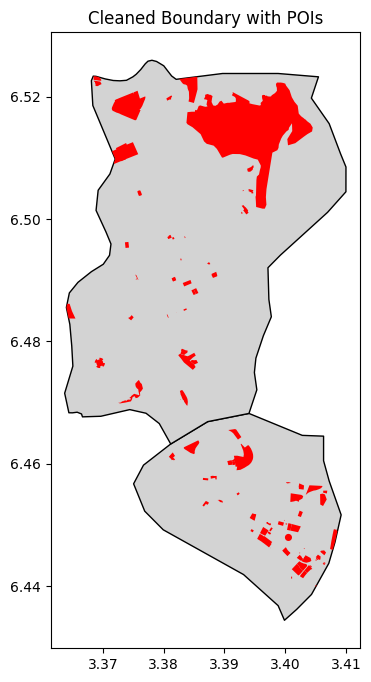

In [132]:
# Quick plot to visualize (e.g., for boundary + POIs)
import matplotlib.pyplot as plt

if boundary_clean is not None and pois_clean_final is not None:
    ax = boundary_clean.plot(figsize=(10, 8), color = 'lightgray', edgecolor = 'black')
    pois_clean_final.plot(ax=ax, color='red', markersize=50)
    ax.set_title ("Cleaned Boundary with POIs")
    plt.show()

else:
    print ("Skipping viz: Missing cleaned layers.")